# Análisis Exploratorio de Datos (EDA) - Riesgo de Crédito

Este cuaderno tiene como objetivo realizar la carga inicial, limpieza y análisis exploratorio de los datos de préstamos. 
El resultado final será un dataset procesado (`df_sample.csv`) con la variable objetivo definida, listo para la etapa de modelado.

## 1. Configuración e Importación de Librerías

Importamos las librerías necesarias para manipulación de datos (`pandas`, `numpy`), gestión de rutas (`pathlib`) y visualización (`matplotlib`, `seaborn`).

In [3]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print(sys.version)
print("cwd:", Path().resolve())

3.11.14 (main, Oct  9 2025, 16:16:55) [Clang 17.0.0 (clang-1700.4.4.1)]
cwd: /Users/mauvilar/Desktop/DA/Proyectos/credit_risk/notebooks


## 2. Carga de Datos

Definimos la ruta al archivo de datos crudos (`data/raw/loan/loan.csv`) y verificamos que el archivo exista antes de intentar leerlo.

In [4]:

DATA_RAW = Path("../data/raw")
LOAN_PATH = DATA_RAW / "loan" / "loan.csv"

print("Exists:", LOAN_PATH.exists())
print("Path:", LOAN_PATH.resolve())

Exists: True
Path: /Users/mauvilar/Desktop/DA/Proyectos/credit_risk/data/raw/loan/loan.csv


Leemos el archivo CSV. Cargamos una muestra inicial (por ejemplo, las primeras 200,000 filas) para agilizar el análisis. Usamos `low_memory=False` para evitar advertencias de tipos de datos mixtos si el archivo es grande.

In [5]:

df_sample = pd.read_csv(LOAN_PATH, low_memory=False, nrows=200_000)
df_sample.shape

(200000, 74)

## 3. Inspección Inicial

Obtenemos información general del dataframe: nombres de columnas, tipos de datos y conteo de valores no nulos.

In [6]:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 74 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           200000 non-null  int64  
 1   member_id                    200000 non-null  int64  
 2   loan_amnt                    200000 non-null  float64
 3   funded_amnt                  200000 non-null  float64
 4   funded_amnt_inv              200000 non-null  float64
 5   term                         200000 non-null  object 
 6   int_rate                     200000 non-null  float64
 7   installment                  200000 non-null  float64
 8   grade                        200000 non-null  object 
 9   sub_grade                    200000 non-null  object 
 10  emp_title                    187513 non-null  object 
 11  emp_length                   192055 non-null  object 
 12  home_ownership               200000 non-null  object 
 13 

Visualizamos las primeras filas para entender el formato de los datos.

In [7]:
df_sample.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,1077501,1296599,5000.0,5000.0,4975.0,36 months,10.65,162.87,B,B2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1077430,1314167,2500.0,2500.0,2500.0,60 months,15.27,59.83,C,C4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1077175,1313524,2400.0,2400.0,2400.0,36 months,15.96,84.33,C,C5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1076863,1277178,10000.0,10000.0,10000.0,36 months,13.49,339.31,C,C1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1075358,1311748,3000.0,3000.0,3000.0,60 months,12.69,67.79,B,B5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Listamos todas las columnas disponibles para empezar a seleccionar cuáles serán útiles para el modelo.

In [8]:
for c in df_sample.columns:
    print(c)

id
member_id
loan_amnt
funded_amnt
funded_amnt_inv
term
int_rate
installment
grade
sub_grade
emp_title
emp_length
home_ownership
annual_inc
verification_status
issue_d
loan_status
pymnt_plan
url
desc
purpose
title
zip_code
addr_state
dti
delinq_2yrs
earliest_cr_line
inq_last_6mths
mths_since_last_delinq
mths_since_last_record
open_acc
pub_rec
revol_bal
revol_util
total_acc
initial_list_status
out_prncp
out_prncp_inv
total_pymnt
total_pymnt_inv
total_rec_prncp
total_rec_int
total_rec_late_fee
recoveries
collection_recovery_fee
last_pymnt_d
last_pymnt_amnt
next_pymnt_d
last_credit_pull_d
collections_12_mths_ex_med
mths_since_last_major_derog
policy_code
application_type
annual_inc_joint
dti_joint
verification_status_joint
acc_now_delinq
tot_coll_amt
tot_cur_bal
open_acc_6m
open_il_6m
open_il_12m
open_il_24m
mths_since_rcnt_il
total_bal_il
il_util
open_rv_12m
open_rv_24m
max_bal_bc
all_util
total_rev_hi_lim
inq_fi
total_cu_tl
inq_last_12m


## 4. Selección de Variables y Definición de Listas

Categorizamos las columnas en grupos lógicos:
*   **Target**: La variable `loan_status` que usaremos para derivar nuestra etiqueta de predicción.
*   **Data Leakage**: Columnas que contienen información del futuro (post-aprobación) y no deben usarse (ej. `recoveries`, `total_pymnt`).
*   **IDs/Texto**: Identificadores únicos o descripciones libres que no aportan al modelo estadístico.
*   **Base Cols**: Las variables que conservaremos como features potenciales.

In [9]:
target_col = "loan_status"

leak_cols = [
    "out_prncp","out_prncp_inv",
    "total_pymnt","total_pymnt_inv",
    "total_rec_prncp","total_rec_int","total_rec_late_fee",
    "recoveries","collection_recovery_fee",
    "last_pymnt_d","last_pymnt_amnt","next_pymnt_d",
    "last_credit_pull_d"
]

id_text_cols = ["id","member_id","url","desc","title","emp_title","policy_code"]

optional_cols = ["grade","sub_grade","int_rate"]

base_cols = [
    "loan_amnt","term","installment",
    "emp_length","home_ownership","annual_inc","verification_status",
    "purpose","addr_state","zip_code","dti",
    "delinq_2yrs","inq_last_6mths","mths_since_last_delinq","mths_since_last_record",
    "open_acc","pub_rec","revol_bal","revol_util","total_acc","initial_list_status",
    "collections_12_mths_ex_med","mths_since_last_major_derog","acc_now_delinq",
    "tot_coll_amt","tot_cur_bal",
    "open_acc_6m","open_il_6m","open_il_12m","open_il_24m",
    "mths_since_rcnt_il","total_bal_il","il_util",
    "open_rv_12m","open_rv_24m","max_bal_bc","all_util","total_rev_hi_lim",
    "inq_fi","total_cu_tl","inq_last_12m",
    "application_type","annual_inc_joint","dti_joint","verification_status_joint"
]

base_cols = [c for c in base_cols if c in df_sample.columns]

X_cols = [c for c in base_cols if c not in leak_cols and c not in id_text_cols and c != target_col]

X_cols[:20], len(X_cols)

(['loan_amnt',
  'term',
  'installment',
  'emp_length',
  'home_ownership',
  'annual_inc',
  'verification_status',
  'purpose',
  'addr_state',
  'zip_code',
  'dti',
  'delinq_2yrs',
  'inq_last_6mths',
  'mths_since_last_delinq',
  'mths_since_last_record',
  'open_acc',
  'pub_rec',
  'revol_bal',
  'revol_util',
  'total_acc'],
 45)

Mostramos algunas listas de variables separadas para verificar.

In [10]:
X_cols_A = X_cols.copy()

X_cols_B = X_cols + [c for c in optional_cols if c in df_sample.columns and c not in X_cols]

len(X_cols_A), len(X_cols_B), X_cols_B[:5]

(45, 48, ['loan_amnt', 'term', 'installment', 'emp_length', 'home_ownership'])

Verificamos la integridad de las listas para asegurarnos de no incluir variables prohibidas.

In [11]:
errors = {}

errors["X_cols_not_in_df"] = [c for c in X_cols if c not in df_sample.columns]
errors["leak_in_X"] = [c for c in X_cols if c in leak_cols]
errors["id_text_in_X"] = [c for c in X_cols if c in id_text_cols]
errors["target_in_X"] = [c for c in X_cols if c == target_col]

errors

{'X_cols_not_in_df': [],
 'leak_in_X': [],
 'id_text_in_X': [],
 'target_in_X': []}

## 5. Análisis de la Variable Objetivo (Target)

Revisamos los valores únicos de `loan_status` para entender los posibles estados de un préstamo.

In [12]:
df_sample[target_col].value_counts(dropna=False).head(20)

loan_status
Fully Paid                                             106186
Current                                                 63870
Charged Off                                             23616
Does not meet the credit policy. Status:Fully Paid       1988
Late (31-120 days)                                       1976
In Grace Period                                          1048
Does not meet the credit policy. Status:Charged Off       761
Late (16-30 days)                                         345
Default                                                   210
Name: count, dtype: int64

### Construcción del Target Binario

Definimos qué constituye un "Mal Crédito" (Target = 1) y un "Buen Crédito" (Target = 0).

*   **Target 1 (Bad):** Charged Off, Default, Late.
*   **Target 0 (Good):** Fully Paid.
*   **Ignorar (NaN):** Current, In Grace Period (a menos que se quiera considerar malo), etc.

In [13]:
# 2) Define qué consideras "malo" y "bueno"
bad_status = {
    "Charged Off",
    "Default",
    "Late (31-120 days)",
    "Late (16-30 days)",
    "In Grace Period"
}

good_status = {
    "Fully Paid"
}

# 3) Crea la variable binaria
df_sample["target_bad"] = np.where(
    df_sample[target_col].isin(bad_status), 1,
    np.where(df_sample[target_col].isin(good_status), 0, np.nan)
)

df_sample["target_bad"].value_counts(dropna=False)

target_bad
0.0    106186
NaN     66619
1.0     27195
Name: count, dtype: int64

## 6. Visualización del Target

Graficamos la distribución porcentual de buenos vs malos créditos. Esto nos ayuda a ver si las clases están desbalanceadas.

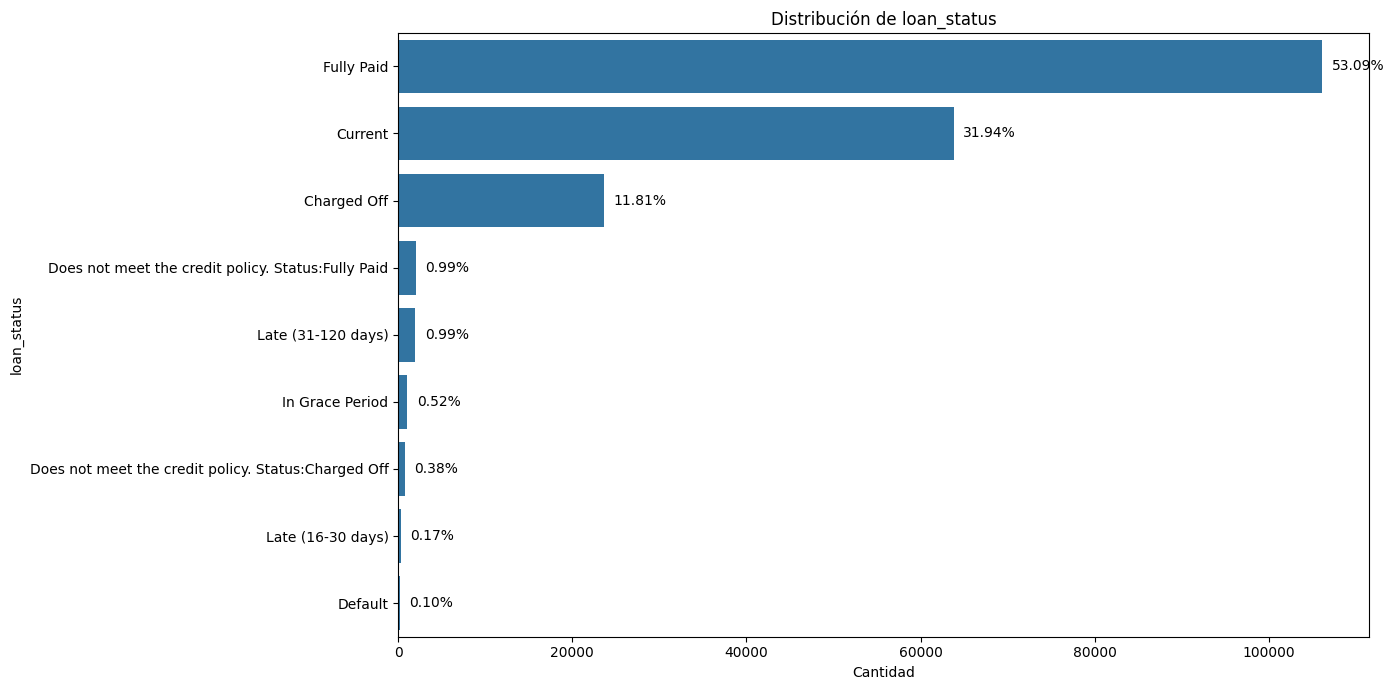

In [14]:

# Cuenta valores del target
counts = df_sample[target_col].value_counts()
plot_df = counts.reset_index()
plot_df.columns = [target_col, "count"]
plot_df["pct"] = plot_df["count"] / plot_df["count"].sum() * 100

# Gráfica
plt.figure(figsize=(14, 7))
ax = sns.barplot(
    data=plot_df,
    y=target_col,
    x="count",
    order=counts.index
)

ax.set_title(f"Distribución de {target_col}")
ax.set_xlabel("Cantidad")
ax.set_ylabel(target_col)

# Etiquetas con porcentaje al final de cada barra
max_x = plot_df["count"].max()
for i, row in plot_df.iterrows():
    ax.text(
        row["count"] + max_x * 0.01,
        i,
        f'{row["pct"]:.2f}%',
        va="center"
    )

plt.tight_layout()
plt.show()

Visualización adicional enfocada en la variable binaria final `target_bad`.

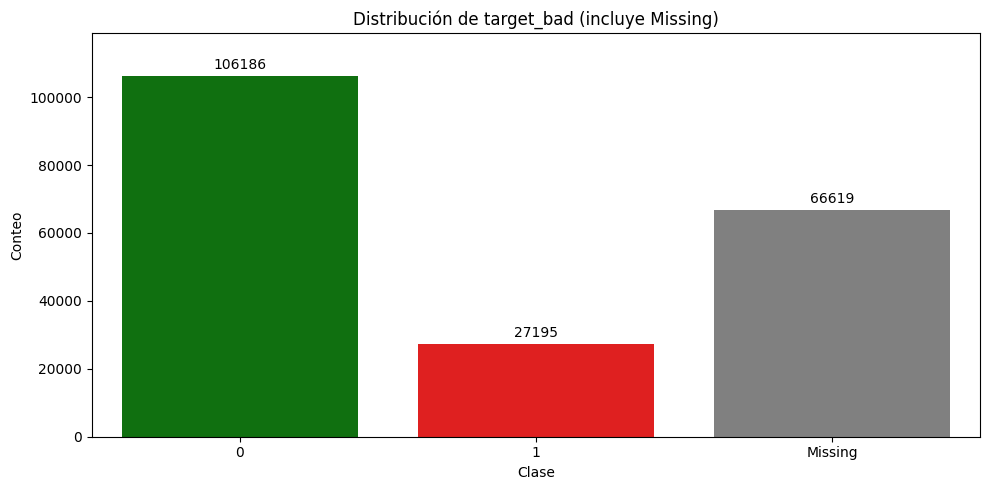

In [15]:

plot_df = df_sample.copy()

plot_df["target_plot"] = plot_df["target_bad"].map({0: "0", 0.0: "0", 1: "1", 1.0: "1"})
plot_df["target_plot"] = plot_df["target_plot"].fillna("Missing")

order = ["0", "1", "Missing"]
palette = {"0": "green", "1": "red", "Missing": "gray"}

plt.figure(figsize=(10, 5))

ax = sns.countplot(
    data=plot_df,
    x="target_plot",
    order=order,
    hue="target_plot",        # evita el warning en seaborn nuevos
    palette=palette,
    dodge=False,
    legend=False
)

plt.title("Distribución de target_bad (incluye Missing)")
plt.xlabel("Clase")
plt.ylabel("Conteo")

# Dar espacio arriba para que quepan los labels
ymax = max([p.get_height() for p in ax.patches]) if ax.patches else 0
ax.set_ylim(0, ymax * 1.12)

# Etiquetas encima de todas las barras
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

## 7. Guardado de Datos

Finalmente, guardamos el dataframe procesado en `../data/df_sample.csv`. Este archivo será la entrada para el cuaderno de `02_models.ipynb`.

In [16]:

Path("data").mkdir(exist_ok=True)

df_sample.to_csv("../data/processed/df_sample.csv", index=False)
print("Guardado: ../data/df_sample.csv")

Guardado: ../data/df_sample.csv
